## 1. Import Necessary Libraries

In [5]:
!pip install lightgbm

     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     ---------- ----------------------------- 0.4/1.4 MB 7.4 MB/s eta 0:00:01
     ---------------------------------------  1.4/1.4 MB 17.2 MB/s eta 0:00:01
     ---------------------------------------  1.4/1.4 MB 17.2 MB/s eta 0:00:01
     ---------------------------------------- 1.4/1.4 MB 7.9 MB/s eta 0:00:00
     ---------------------------------------- 0.0/467.4 kB ? eta -:--:--
     ------------------------------------- 467.4/467.4 kB 30.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd

from sklearn.preprocessing import LabelEncoder # To encode the classify column to numberic 
from sklearn.model_selection import train_test_split

from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier  
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix  # those metrics are mainly for evaluating a Classification model  

import warnings
warnings.filterwarnings("ignore")

# AdaBoost             → Focuses more on incorrectly predicted observations
# Gradient Boosting    → Sequentially learns from previous errors
# Classifier           → Predicts categories
# Ensemble             → Combines multiple models

# from xgboost import XGBClassifier
# from lightgbm import LGBMClassifier
# We import XGBClassifier and LGBMClassifier because they are boosting-based classification algorithms. We can train them on the same training data, evaluate them on the test data, and compare their performance with other classification models.

## 2. Import Dataset

In [7]:
credit_card_data = pd.read_csv("credit_card_clean.csv")
credit_card_data

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,female,university,married,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,female,university,single,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,female,university,single,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,female,university,married,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,male,university,married,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,male,highschool,married,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,male,highschool,single,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,male,university,single,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,male,highschool,married,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


## 3. Data Understanding

### Exploring the variable
* ID : ID of each client

* LIMIT_BAL: Amount of given credit in NT dollars (includes individual and family/supplementary credit)

* SEX: Gender (1=male, 2=female)

* EDUCATION: (1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown)

* MARRIAGE: Marital status (1=married, 2=single, 3=others)

* AGE: Age in years

* PAY_1: Repayment status in September, 2005 (-2 = No consumption, -1 = paid in full, 0 = use of revolving credit (paid minimum only), 1 = payment delay for one month, 2 = payment delay for two months, ... 8 = payment delay for eight months, 9 = payment delay for nine months and above)

* PAY_2: Repayment status in August, 2005 (scale same as above)

* PAY_3: Repayment status in July, 2005 (scale same as above)

* PAY_4: Repayment status in June, 2005 (scale same as above)

* PAY_5: Repayment status in May, 2005 (scale same as above)

* PAY_6: Repayment status in April, 2005 (scale same as above)

* BILL_AMT1: Amount of bill statement in September, 2005 (NT dollar)

* BILL_AMT2: Amount of bill statement in August, 2005 (NT dollar)

* BILL_AMT3: Amount of bill statement in July, 2005 (NT dollar)

* BILL_AMT4: Amount of bill statement in June, 2005 (NT dollar)

* BILL_AMT5: Amount of bill statement in May, 2005 (NT dollar)

* BILL_AMT6: Amount of bill statement in April, 2005 (NT dollar)

* PAY_AMT1: Amount of previous payment in September, 2005 (NT dollar)

* PAY_AMT2: Amount of previous payment in August, 2005 (NT dollar)

* PAY_AMT3: Amount of previous payment in July, 2005 (NT dollar)

* PAY_AMT4: Amount of previous payment in June, 2005 (NT dollar)

* PAY_AMT5: Amount of previous payment in May, 2005 (NT dollar)

* PAY_AMT6: Amount of previous payment in April, 2005 (NT dollar)

#### Target variable
default.payment.next.month: Default payment (1=yes, 0=no)

###### Note: NT is Taiwain Dollars

## 3. Data Understanding

In [4]:
credit_card_data.isna().sum()

ID           0
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_1        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64

In [5]:
credit_card_data.dtypes

ID             int64
LIMIT_BAL    float64
SEX           object
EDUCATION     object
MARRIAGE      object
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

In [ ]:
# Since Sex, Education, marriage datasets seems to be numberic we need to encode the data.

In [6]:
credit_card_data.shape

(30000, 25)

## 4. Data Preparation

In [7]:
del credit_card_data["ID"] # Since Machine Learning does not learn the pattern with unique items "ID" column can be removed

In [8]:
credit_card_data

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000.0,female,university,married,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,female,university,single,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,female,university,single,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,female,university,married,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,male,university,married,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,220000.0,male,highschool,married,39,0,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,150000.0,male,highschool,single,43,-1,-1,-1,-1,0,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,30000.0,male,university,single,37,4,3,2,-1,0,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,80000.0,male,highschool,married,41,1,-1,0,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [28]:
le = LabelEncoder()
credit_card_data["SEX"] = le.fit_transform(credit_card_data["SEX"])
credit_card_data["EDUCATION"] = le.fit_transform(credit_card_data["EDUCATION"])
credit_card_data["MARRIAGE"] = le.fit_transform(credit_card_data["MARRIAGE"])
credit_card_data
# labelencode is used to convert the categorical classification to numberic values

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,0,3,0,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,0,3,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,0,3,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,0,3,0,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,3,0,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000.0,1,1,0,39,0,0,0,0,...,88004.0,31237.0,15980.0,8500.0,20000.0,5003.0,3047.0,5000.0,1000.0,0
29996,29997,150000.0,1,1,2,43,-1,-1,-1,-1,...,8979.0,5190.0,0.0,1837.0,3526.0,8998.0,129.0,0.0,0.0,0
29997,29998,30000.0,1,3,2,37,4,3,2,-1,...,20878.0,20582.0,19357.0,0.0,0.0,22000.0,4200.0,2000.0,3100.0,1
29998,29999,80000.0,1,1,0,41,1,-1,0,0,...,52774.0,11855.0,48944.0,85900.0,3409.0,1178.0,1926.0,52964.0,1804.0,1


In [29]:
credit_card_data.dtypes # Now its changed

ID             int64
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_1          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
DEFAULT        int64
dtype: object

## 5. Model Building

In [30]:
X = credit_card_data.drop("DEFAULT",axis=1) # x - inupt and y- tagert(o/p)
y = credit_card_data["DEFAULT"]             # Removing the tagert output column

In [22]:
X.shape,y.shape

((30000, 24), (30000,))

In [31]:
# train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=123,shuffle=True,stratify=y)

In [24]:
X_train.shape,y_train.shape

((24000, 24), (24000,))

In [25]:
X_test.shape,y_test.shape  # 6000 observation for testing model

((6000, 24), (6000,))

## 6. Model Training

#### Training Time Analysis

In [65]:
# Using each Boost alogrirthim 
adb_classifier  = AdaBoostClassifier()
gb_classifier   = GradientBoostingClassifier(n_estimators=50)
xgb_classifier  = XGBClassifier(n_estimators = 200)
lgbm_classifier = LGBMClassifier(n_estimators = 200)

In [66]:
%%time
adb_classifier.fit(X_train,y_train) 

# CPU - This means your computer's CPU spent about 3 seconds doing the work.
# Wall time - This is the actual time you waited from the beginning to the end of execution.

CPU times: total: 3.52 s
Wall time: 4.09 s


,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [40]:
%%time
gb_classifier.fit(X_train,y_train) # GB Wall time (Training time) should be > than Adaboost

CPU times: total: 8.3 s
Wall time: 8.66 s


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [45]:
%%time
xgb_classifier.fit(X_train,y_train)  # XGB Wall time (Training time) should be < than Garient Boost

CPU times: total: 2.06 s
Wall time: 738 ms


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
%%time
lgbm_classifier.fit(X_train,y_train) # LXGB Wall time (Training time) should be < than Extreme Garient Boost

[LightGBM] [Info] Number of positive: 5309, number of negative: 18691
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3514
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.221208 -> initscore=-1.258639
[LightGBM] [Info] Start training from score -1.258639
CPU times: total: 1.91 s
Wall time: 862 ms


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


## 7. Model Testing

In [34]:
y_pred_adb = adb_classifier.predict(X_test)
y_pred_gb  = gb_classifier.predict(X_test)
y_pred_xgb = xgb_classifier.predict(X_test)
y_pred_lgb = lgbm_classifier.predict(X_test)

# Model testing for all boosting

## 8. Model Evaluation

### Adaboost Evaluation

In [43]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_adb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_adb),4))
print("Recall Score",round(recall_score(y_test,y_pred_adb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_adb))

Accuracy Score: 0.8218
Precision Score: 0.7048
Recall Score 0 4
Confusion Matrix
 [[4487  186]
 [ 883  444]]


#### Gradient Boosting

In [44]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_gb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_gb),4))
print("Recall Score",round(recall_score(y_test,y_pred_gb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_gb))

Accuracy Score: 0.8233
Precision Score: 0.6949
Recall Score 0 4
Confusion Matrix
 [[4464  209]
 [ 851  476]]


### XGBM 

In [45]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_xgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_xgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_xgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_xgb))

Accuracy Score: 0.8185
Precision Score: 0.6617
Recall Score 0 4
Confusion Matrix
 [[4424  249]
 [ 840  487]]


### LGBM

In [46]:
print("Accuracy Score:",round(accuracy_score(y_test,y_pred_lgb),4))
print("Precision Score:",round(precision_score(y_test,y_pred_lgb),4))
print("Recall Score",round(recall_score(y_test,y_pred_lgb)),4)
print("Confusion Matrix\n",confusion_matrix(y_test,y_pred_lgb))

Accuracy Score: 0.8248
Precision Score: 0.696
Recall Score 0 4
Confusion Matrix
 [[4459  214]
 [ 837  490]]


## Let's Learn Feature Importance

In [47]:
adb_feature_imp = adb_classifier.feature_importances_ # Calling the model trained variable name
gb_feature_imp  = gb_classifier.feature_importances_
xgb_feature_imp = xgb_classifier.feature_importances_
lgb_feature_imp = lgbm_classifier.feature_importances_

##### This is used to find which input features are most important for making predictions.

* You have four models:

* AdaBoost
* Gradient Boosting
* XGBoost
* LightGBM

And each model can tell you how important each feature was.

In [46]:
X.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

In [50]:
# Naming the new features coulumn name
feature_importance_list = pd.DataFrame(data = { "Features":X.columns,
                                                 "Adaboost_Features":adb_feature_imp,
                                                 "GB_Feature":gb_feature_imp,
                                                 "XGB Features":xgb_feature_imp,
                                                 "LGB_Features":lgb_feature_imp})
feature_importance_list

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
0,ID,0.000000,0.012704,0.021831,639
1,LIMIT_BAL,0.057269,0.025037,0.025957,379
2,SEX,0.000000,0.001927,0.020472,50
3,EDUCATION,0.000000,0.001416,0.022638,98
4,MARRIAGE,0.017747,0.002634,0.020202,72
5,AGE,0.000000,0.002902,0.021042,375
6,PAY_1,0.513985,0.650191,0.319567,161
7,PAY_2,0.035080,0.093085,0.095334,77
8,PAY_3,0.052493,0.041121,0.053866,74
9,PAY_4,0.004686,0.015746,0.034800,58


### Question 1 - Display the Top 10 Features of Adaboost

In [51]:
import seaborn as sns

In [53]:
adaboost_top_features = feature_importance_list.sort_values(by = "Adaboost_Features",ascending = False)
adaboost_top_features.head(10)

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
6,PAY_1,0.513985,0.650191,0.319567,161
18,PAY_AMT1,0.087824,0.020567,0.024992,371
19,PAY_AMT2,0.064727,0.018342,0.025147,373
1,LIMIT_BAL,0.057269,0.025037,0.025957,379
8,PAY_3,0.052493,0.041121,0.053866,74
11,PAY_6,0.042327,0.020618,0.035080,64
20,PAY_AMT3,0.037968,0.022367,0.028273,348
7,PAY_2,0.035080,0.093085,0.095334,77
21,PAY_AMT4,0.019563,0.010181,0.023958,320
16,BILL_AMT5,0.018466,0.000336,0.023133,271


<Axes: xlabel='Adaboost_Features', ylabel='Features'>

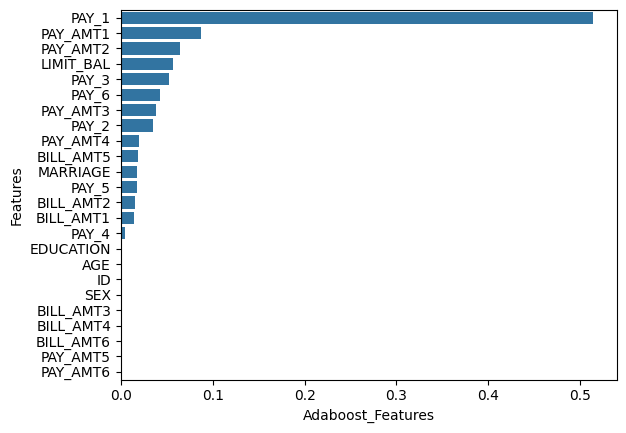

In [54]:
sns.barplot(data=adaboost_top_features,y="Features",x="Adaboost_Features",)

### Try with Gradient Boosting_Feature

In [55]:
gbboost_top_features = feature_importance_list.sort_values(by = "GB_Feature",ascending = False)
top_10_gb_features = gbboost_top_features.head(10)
top_10_gb_features

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
6,PAY_1,0.513985,0.650191,0.319567,161
7,PAY_2,0.035080,0.093085,0.095334,77
8,PAY_3,0.052493,0.041121,0.053866,74
1,LIMIT_BAL,0.057269,0.025037,0.025957,379
20,PAY_AMT3,0.037968,0.022367,0.028273,348
12,BILL_AMT1,0.014796,0.021755,0.026575,384
11,PAY_6,0.042327,0.020618,0.035080,64
18,PAY_AMT1,0.087824,0.020567,0.024992,371
19,PAY_AMT2,0.064727,0.018342,0.025147,373
9,PAY_4,0.004686,0.015746,0.034800,58


<Axes: xlabel='GB_Feature', ylabel='Features'>

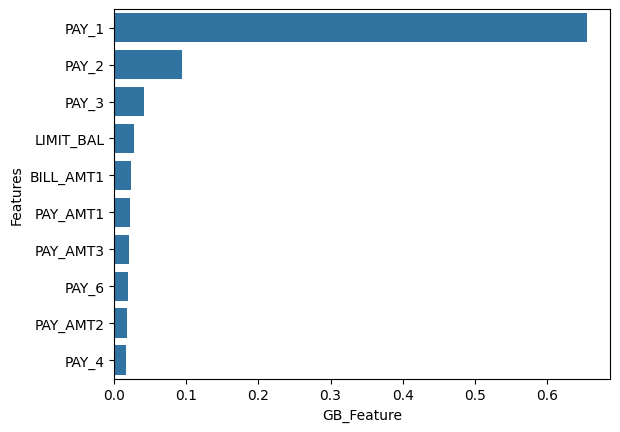

In [85]:
sns.barplot(data=top_10_gb_features,y="Features",x="GB_Feature",)

## THE END!!

# Why do we need Feature Importance?

In [ ]:
Your dataset has many columns:

LIMIT_BAL
SEX
EDUCATION
MARRIAGE
AGE
PAY_1
PAY_2
PAY_3
...
BILL_AMT1
...
PAY_AMT6

# You want to understand:

Which variables are actually important when predicting DEFAULT?

Feature importance helps answer that.

# For example, suppose the result is:

Feature	Importance
PAY_1	0.30
LIMIT_BAL	0.18
PAY_2	0.12
AGE	0.07
SEX	0.01

You could say:

PAY_1 is more influential in the model's predictions than SEX.

In [ ]:
Important distinction

Feature importance does NOT mean:

"PAY_1 causes the customer to default."

It means:

"PAY_1 was useful to the model when making its predictions."

That's an important difference.

Why calculate it for all 4 models?

You can compare whether the models are identifying similar important features.

For example:

                Most Important
AdaBoost        PAY_1
GradientBoost   PAY_1
XGBoost         PAY_1
LightGBM        PAY_1

If several models identify the same feature as highly important, that gives you useful insight into the dataset.

#### Interview answer

“Feature importance tells us how much each input feature contributes to the model's predictions. We extract feature importance from AdaBoost, Gradient Boosting, XGBoost, and LightGBM so that we can understand and compare which variables are most influential in predicting the target variable.”

In [ ]:
#### Testsed for XGB 

In [57]:
XGB_top_features = feature_importance_list.sort_values(by = "XGB Features",ascending = False)
XGB_top_features  = XGB_top_features .head(10)
XGB_top_features 

,Features,Adaboost_Features,GB_Feature,XGB Features,LGB_Features
6,PAY_1,0.513985,0.650191,0.319567,161
7,PAY_2,0.035080,0.093085,0.095334,77
8,PAY_3,0.052493,0.041121,0.053866,74
10,PAY_5,0.017710,0.012753,0.040597,47
11,PAY_6,0.042327,0.020618,0.035080,64
9,PAY_4,0.004686,0.015746,0.034800,58
20,PAY_AMT3,0.037968,0.022367,0.028273,348
12,BILL_AMT1,0.014796,0.021755,0.026575,384
1,LIMIT_BAL,0.057269,0.025037,0.025957,379
19,PAY_AMT2,0.064727,0.018342,0.025147,373


<Axes: xlabel='XGB Features', ylabel='Features'>

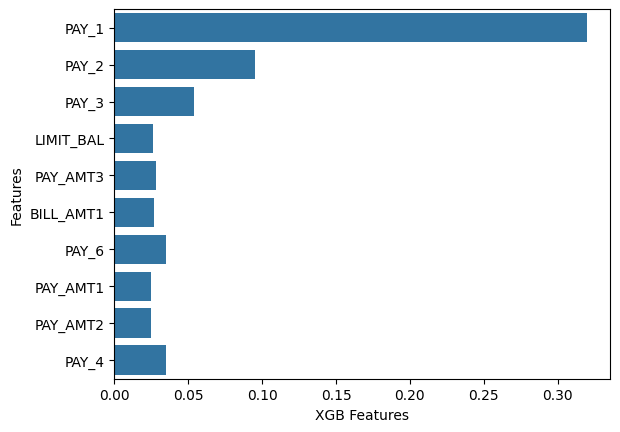

In [58]:
sns.barplot(data=top_10_gb_features,y="Features",x="XGB Features",)